#**Data Cleaning Assignment Answers**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('healthcare_data_cleaning_dataset.csv')

In [7]:
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [5]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (5100, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          5100 non-null   int64  
 1   Age                 4500 non-null   float64
 2   Gender              5100 non-null   object 
 3   City                5100 non-null   object 
 4   Diagnosis           5100 non-null   object 
 5   Hospital_Visits     5100 non-null   int64  
 6   Treatment_Cost      4507 non-null   float64
 7   Insurance_Coverage  5100 non-null   int64  
 8   Admission_Date      5100 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 358.7+ KB


**Q1. Missing Data Identification**

Scenario:
 The hospital suspects incomplete patient records.

Task:

* Identify missing values in each column

* Calculate percentage of missing data

In [6]:
# Identify missing values in each column
missing_count = df.isnull().sum()

# Calculate the percentage of missing data
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine the results into a single summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percentage
})

print("--- Missing Data Summary ---")
print(missing_summary)

--- Missing Data Summary ---
                    Missing Count  Percentage (%)
Patient_ID                      0        0.000000
Age                           600       11.764706
Gender                          0        0.000000
City                            0        0.000000
Diagnosis                       0        0.000000
Hospital_Visits                 0        0.000000
Treatment_Cost                593       11.627451
Insurance_Coverage              0        0.000000
Admission_Date                  0        0.000000


**Q2. Handling Missing Age**

Scenario:

  Age is critical for medical analysis, but some values are missing.

Task:

* Replace missing Age values with an appropriate method

* Justify your choice (mean/median)

In [8]:
# Check skewness to justify our choice
age_skew = df['Age'].skew()
print(f"Age Skewness: {age_skew:.4f}")



Age Skewness: -0.0098


In [9]:
# Since skewness is near 0, the distribution is symmetric. Let's use the median.
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

print(f"Remaining missing values in 'Age': {df['Age'].isnull().sum()}")

Remaining missing values in 'Age': 0


We will use the median here as it is a safe and standard central tendency practice.

**Q3. Handling Missing Treatment Cost**

Scenario:
 Treatment cost is highly skewed due to expensive treatments.

Task:

* Handle missing Treatment_Cost values

* Choose the correct imputation method and explain why

In [10]:
# Check skewness of Treatment_Cost
cost_skew = df['Treatment_Cost'].skew()
print(f"Treatment Cost Skewness: {cost_skew:.4f}")


Treatment Cost Skewness: 4.4857


In [11]:
# Highly skewed distribution -> Impute with the Median
cost_median = df['Treatment_Cost'].median()
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(cost_median)

print(f"Remaining missing values in 'Treatment_Cost': {df['Treatment_Cost'].isnull().sum()}")

Remaining missing values in 'Treatment_Cost': 0


For highly skewed datasets, the mean is heavily distorted by extreme high-value outliers (expensive treatments). Therefore, the median is the correct imputation method because it reflects the true central tendency without being influenced by extreme values.

**Q4. Duplicate Patient Records**

Scenario:
 Some patient records were entered multiple times.

Task:

* Identify duplicate rows

* Remove duplicates

* Compare dataset size before and after

In [12]:
# Identify duplicate rows
duplicate_count = df.duplicated().sum()
print(f"num of duplicate rows: {duplicate_count}")

Number of duplicate rows found: 99


In [13]:
# Compare dataset size before and after removal
size_before = df.shape[0]
df = df.drop_duplicates()
size_after = df.shape[0]

print(f"Dataset size BEFORE removing duplicates: {size_before} rows")
print(f"Dataset size AFTER removing duplicates: {size_after} rows")
print(f"Total rows removed: {size_before - size_after}")

Dataset size BEFORE removing duplicates: 5100 rows
Dataset size AFTER removing duplicates: 5001 rows
Total rows removed: 99


**Q5. Invalid Age Values (Data Quality Check)**

Scenario:
 Some patients have unrealistic age values (e.g., >100 or <0).

Task:

* Detect such records

* Decide whether to remove or correct them

In [14]:
# Detecting records with unrealistic age values
invalid_ages = df[(df['Age'] < 0) | (df['Age'] > 100)]
print(f"Number of invalid age records (<0 or >100): {len(invalid_ages)}")

Number of invalid age records (<0 or >100): 0


In [15]:
# Decision block
if len(invalid_ages) > 0:
    print("Invalid age entries detected. Removing records...")
    df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]
else:
    print("No invalid age records found. Data quality check passed successfully!")

No invalid age records found. Data quality check passed successfully!


**Q6. Outlier Detection (Treatment Cost)**

Scenario:
 Extreme treatment costs are affecting analysis.

Task:

* Detect outliers using IQR method

* Display number of outliers

In [16]:
# Calculate Q1, Q3, and IQR
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]

print(f"Q1 (25th Percentile): {Q1}")
print(f"Q3 (75th Percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Outlier Thresholds: Lower Bound = {lower_bound}, Upper Bound = {upper_bound}")
print(f"Number of outliers detected: {len(outliers)}")

Q1 (25th Percentile): 13766.0
Q3 (75th Percentile): 36542.0
IQR: 22776.0
Outlier Thresholds: Lower Bound = -20398.0, Upper Bound = 70706.0
Number of outliers detected: 50


**Q7. Outlier Treatment**

Scenario:
The business team wants to retain all records.

Task:

* Apply capping (Winsorization) on Treatment_Cost

* Use 5th and 95th percentile

In [20]:
# Calculating the 5th and 95th percentiles
p5 = df['Treatment_Cost'].quantile(0.05)
p95 = df['Treatment_Cost'].quantile(0.95)

print(f"5th Percentile value (Lower Cap): {p5}")
print(f"95th Percentile value (Upper Cap): {p95}")

# Applying capping using numpy clip
df['Treatment_Cost_Capped'] = np.clip(df['Treatment_Cost'], p5, p95)

print("\nVerify Capping:")
print(f"Minimum cost after capping: {df['Treatment_Cost_Capped'].min()}")
print(f"Maximum cost after capping: {df['Treatment_Cost_Capped'].max()}")

5th Percentile value (Lower Cap): 3238.0
95th Percentile value (Upper Cap): 47948.0

Verify Capping:
Minimum cost after capping: 3238.0
Maximum cost after capping: 47948.0


**Q8. Transformation**

Scenario:
 Treatment cost is highly skewed.

Task:

* Apply log transformation

* Create a new column

* Compare before vs after distribution

Skewness before Log Transformation: 4.7476
Skewness after Log Transformation: -1.2326


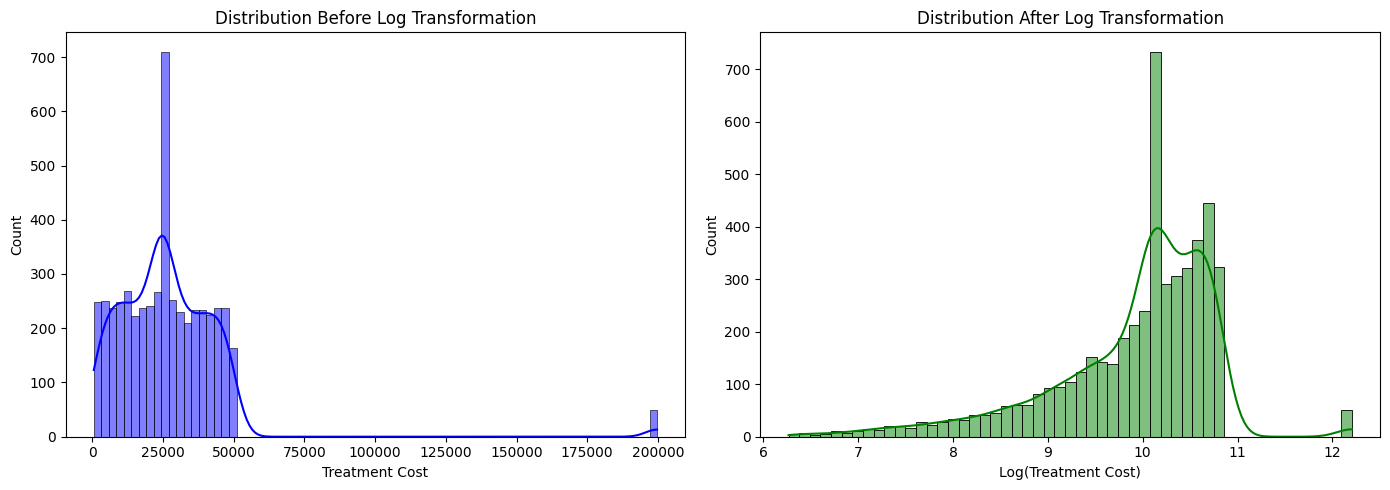

In [23]:
# Apply log transformation (using log1p to handle any potential 0 values safely)
df['Treatment_Cost_Log'] = np.log1p(df['Treatment_Cost'])

print(f"Skewness before Log Transformation: {df['Treatment_Cost'].skew():.4f}")
print(f"Skewness after Log Transformation: {df['Treatment_Cost_Log'].skew():.4f}")

# Plotting the distributions to compare before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution before log transformation
sns.histplot(df['Treatment_Cost'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution Before Log Transformation')
axes[0].set_xlabel('Treatment Cost')

# Distribution after log transformation
sns.histplot(df['Treatment_Cost_Log'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution After Log Transformation')
axes[1].set_xlabel('Log(Treatment Cost)')

plt.tight_layout()
plt.show()

**Q9. Time-Based Missing Handling**

Scenario:
 Admission dates should follow a logical sequence.

Task:

* Sort data by Admission_Date

* Apply forward fill or backward fill where appropriate

* Justify your choice

In [24]:
# Load a fresh dataset copy to demonstrate timeline-based filling
df_time = pd.read_csv('healthcare_data_cleaning_dataset.csv')

# Ensure Admission_Date is converted to standard datetime objects
df_time['Admission_Date'] = pd.to_datetime(df_time['Admission_Date'])

# Sort data sequentially by Admission_Date
df_time = df_time.sort_values(by='Admission_Date').reset_index(drop=True)

print("Missing values before time-based filling:")
print(df_time.isnull().sum())

# Apply forward fill first, then backward fill as fallback
df_time_filled = df_time.ffill().bfill()

print("\nMissing values after time-based filling (ffill + bfill):")
print(df_time_filled.isnull().sum())

Missing values before time-based filling:
Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64

Missing values after time-based filling (ffill + bfill):
Patient_ID            0
Age                   0
Gender                0
City                  0
Diagnosis             0
Hospital_Visits       0
Treatment_Cost        0
Insurance_Coverage    0
Admission_Date        0
dtype: int64


When handling missing values across sequential/chronological timelines, Forward Fill (ffill) is the standard approach because it copies the last observed valid record forward to fill the blank. This ensures there is no "lookahead bias" (accidentally using future records to fill the past).